# Refining real powder data with Sessions

We are going to refine the complete NIST SRM 660c LaB₆ powder pattern. The file has 5,332 measured points. We will give the same pattern two structural models and let BraggCalculator fit both.

Along the way we will:

1. load and plot the experiment;
2. make two candidate structures;
3. choose which parameters may change;
4. run a `RefinementSession`;
5. inspect fits, residuals, loss curves, and parameter correlations;
6. continue a refinement from a checkpoint;
7. save a CIF, JSON result, and HTML report;
8. run a `PhaseMixtureSession`.


## 1. Read the pattern and instrument details

Start with the measured XYE file. It contains `2theta`, intensity, and sigma. We also record the Cu emission lines, goniometer radius, and specimen displacement because they affect the calculated peaks.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from pymatgen.core import Lattice, Structure
from pymatgen.io.cif import CifWriter

from braggcalculator import (
    DiffractionDataset,
    OptimizationStage,
    PhaseMixturePolicy,
    PhaseMixtureSession,
    RefinementPolicy,
    RefinementSession,
    nist_copper_ka_spectrum,
    policy_to_dict,
    refined_structure_from_candidate,
    session_result_to_dict,
)

ROOT = Path.cwd().resolve()
if not (ROOT / "braggcalculator").is_dir():
    ROOT = next((p for p in ROOT.parents if (p / "braggcalculator").is_dir()), ROOT)
OUTPUT = ROOT / "notebooks" / "session-tutorial-output"
OUTPUT.mkdir(parents=True, exist_ok=True)

metadata = {
    "sample": "NIST SRM 660c LaB6",
    "scan": "100a",
    "source": "ark:/88434/mds2-2315",
    "wavelength_components": nist_copper_ka_spectrum(),
    "reference_lattice_angstrom": 4.156826,
    "reference_lattice_expanded_uncertainty_angstrom": 0.000080,
    "instrument": {
        "geometry": "Bragg-Brentano",
        "goniometer_radius_mm": 217.5,
        "reported_specimen_displacement_mm": -0.07877,
    },
}
dataset = DiffractionDataset.from_xye(
    ROOT / "data" / "nist_srm660c_100a_full.xye",
    wavelength=1.5405925, radiation="xray", metadata=metadata,
)
print(f"{len(dataset.coordinate):,} points from {dataset.coordinate[0]:.3f}° to {dataset.coordinate[-1]:.3f}° 2theta")
print("Input SHA256:", dataset.source_sha256)


5,332 points from 20.300° to 150.908° 2theta
Input SHA256: 64dfe2d550196ca6deb5f27ebe55d7f50d6c6ff105ce1d0ac64d67da01082a55


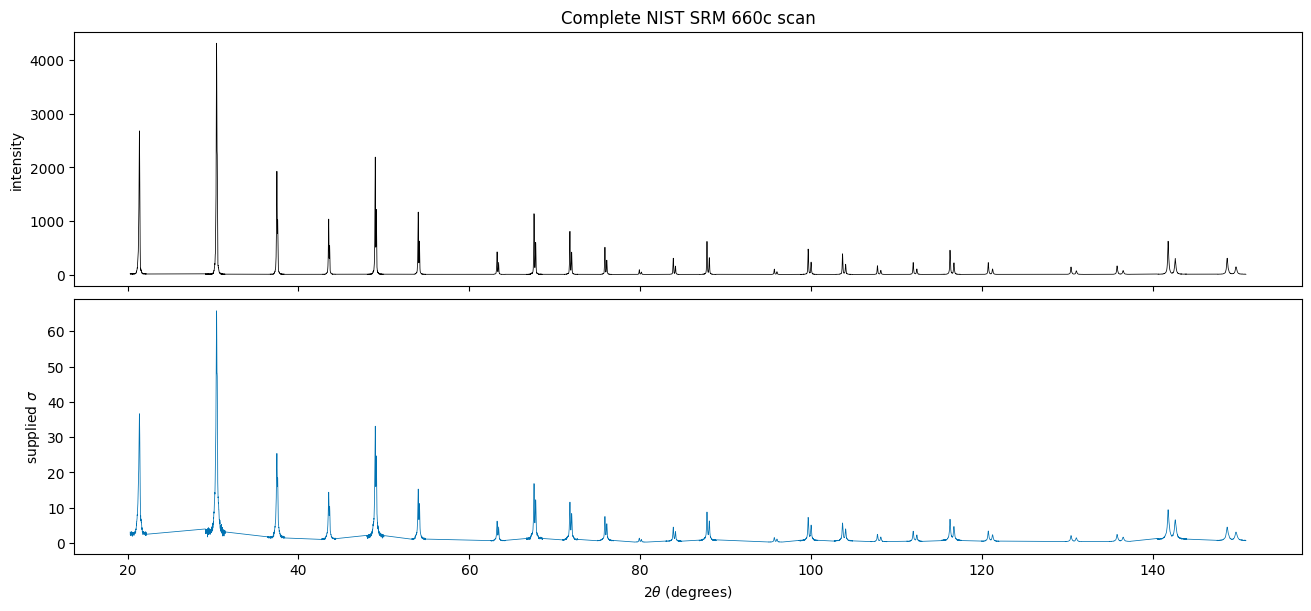

{'full points': 5332,
 'select_range(20.3, 60.0) points': 1258,
 'exclude([(44.0, 44.2)]) retained points': 5311,
 'dataset used below': 'the full scan'}

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
axes[0].plot(dataset.coordinate, dataset.intensity, color="black", lw=0.55)
axes[0].set(ylabel="intensity", title="Complete NIST SRM 660c scan")
axes[1].plot(dataset.coordinate, dataset.sigma, color="#0072B2", lw=0.55)
axes[1].set(xlabel=r"$2\theta$ (degrees)", ylabel=r"supplied $\sigma$")
plt.show()

# Dataset helpers return new immutable datasets; the original is unchanged.
low_angle_window = dataset.select_range(20.3, 60.0)
example_mask = dataset.exclude([(44.0, 44.2)])
display({
    "full points": len(dataset.coordinate),
    "select_range(20.3, 60.0) points": len(low_angle_window.coordinate),
    "exclude([(44.0, 44.2)]) retained points": int(example_mask.mask.sum()),
    "dataset used below": "the full scan",
})


The top graph is the measured pattern. Peak positions mostly tell us about the unit cell. Peak heights depend strongly on the atoms and their positions. Peak widths come from the instrument and the sample.

The lower graph is the uncertainty supplied with each point. A small \(\sigma\) gives that point more weight during refinement. `select_range()` cuts out a useful angular window. `exclude()` marks a region to leave out of a fit. We keep the full scan for the calculations below.

## 2. Make two candidate structures

The first candidate starts with a short unit cell and a shifted boron position. The second comes from the NIST certificate CIF. Both are LaB₆ in space group Pm-3m.

`RefinementSession` will fit each candidate separately against the same measured pattern.


In [3]:
certificate_model = Structure.from_file(ROOT / "data" / "LaB6_srm660c.cif")
perturbed_model = Structure.from_spacegroup(
    "Pm-3m", Lattice.cubic(4.145),
    ["La", "B"], [[0, 0, 0], [0.205, 0.5, 0.5]],
)
models = [perturbed_model, certificate_model]
model_names = ["perturbed B coordinate", "certificate model"]
display([
    {
        "candidate": name,
        "formula": model.composition.reduced_formula,
        "space group": model.get_space_group_info()[0],
        "a (angstrom)": model.lattice.a,
        "representative B x": min(
            abs(float(site.frac_coords[axis]))
            for site in model if site.species_string == "B"
            for axis in range(3) if not np.isclose(site.frac_coords[axis], 0.5)
        ),
    }
    for name, model in zip(model_names, models)
])


[{'candidate': 'perturbed B coordinate',
  'formula': 'LaB6',
  'space group': 'Pm-3m',
  'a (angstrom)': 4.145,
  'representative B x': 0.205},
 {'candidate': 'certificate model',
  'formula': 'LaB6',
  'space group': 'Pm-3m',
  'a (angstrom)': 4.15678,
  'representative B x': 0.198}]

The two starting points differ in two places. The perturbed model has \(a=4.145\) Å and boron \(x=0.205\). The certificate model has \(a=4.15678\) Å and boron \(x=0.198\). Changing \(a\) moves the peaks left or right. Changing boron \(x\) changes their relative heights.

## 3. Meet the Session tools

| Object or function | What it does |
|---|---|
| `RefinementPolicy.quick(...)` | A short ready-made sequence |
| `RefinementPolicy.cautious(...)` | A longer sequence with separate structural stages |
| `RefinementPolicy.robust(...)` | A coarse-to-fine sequence with restarts and an L-BFGS finish |
| `OptimizationStage(...)` | One block of optimizer steps and the parameters active in that block |
| `RefinementSession(dataset, models, names=...)` | Puts the pattern and candidate models together |
| `session.refine_candidate(index, policy, checkpoint=...)` | Refines one chosen candidate |
| `session.run(policy, checkpoints=...)` | Refines every candidate and returns a ranked result |
| `session.write_html(result, path)` | Saves a readable report |
| `refined_structure_from_candidate(candidate, dataset)` | Builds a structure with the refined values |
| `session_result_to_dict(result, run_id=...)` | Makes a JSON-ready result |
| `PhaseMixtureSession(...)` | Fits several phases together |


In [4]:
recipes = {
    "quick": RefinementPolicy.quick(refine_coordinates=True),
    "cautious": RefinementPolicy.cautious(refine_coordinates=True),
    "robust": RefinementPolicy.robust(refine_coordinates=True, restarts=3),
}
display([
    {
        "recipe": name,
        "stages": [stage.name for stage in policy.stages],
        "total optimizer steps per attempt": sum(stage.steps for stage in policy.stages),
        "restarts used by session.run": policy.restarts,
        "adaptive release": policy.adaptive_release,
    }
    for name, policy in recipes.items()
])


[{'recipe': 'quick',
  'stages': ['scale/background', 'calibration/profile', 'joint'],
  'total optimizer steps per attempt': 200,
  'restarts used by session.run': 1,
  'adaptive release': False},
 {'recipe': 'cautious',
  'stages': ['scale/background',
   'calibration/profile',
   'coordinates',
   'joint'],
  'total optimizer steps per attempt': 700,
  'restarts used by session.run': 1,
  'adaptive release': False},
 {'recipe': 'robust',
  'stages': ['wide profile',
   'intermediate profile',
   'physical profile',
   'L-BFGS polish'],
  'total optimizer steps per attempt': 420,
  'restarts used by session.run': 3,
  'adaptive release': True}]

The recipes differ mainly in how many stages they use. `quick` gets a first result in 200 optimizer steps. `cautious` separates coordinates from the other terms. `robust` repeats the fit from several starting points and ends with L-BFGS. For this run we will write our own three-stage policy so we can see each part clearly.

## 4. Write the refinement steps

We will fit scale and background first, then add the more tightly coupled terms:

1. scale and background;
2. peak profile and cubic lattice parameter;
3. all of those together.

The coordinate parameter is created here as well. We will switch it on later when we continue from the saved checkpoint. `restarts` controls how many complete attempts `session.run()` makes for each candidate.


In [5]:
profile_policy = RefinementPolicy(
    background_degree=6,
    profile_model="tch",
    axial_asymmetry=True,
    goniometer_radius_mm=217.5,
    specimen_displacement_mm=-0.07877,
    refine_lattice=True,
    refine_coordinates=True,       # declared for checkpoint compatibility
    coordinate_restraint=0.05,
    holdout_stride=10,
    restarts=1,
    diagnostic_points=24,
    stages=(
        OptimizationStage(
            "scale/background", ("scale", "background"), 50, 0.03
        ),
        OptimizationStage(
            "profile/lattice", ("profile", "lattice"), 100, 0.01
        ),
        OptimizationStage(
            "joint profile polish",
            ("scale", "background", "profile", "lattice"),
            150, 0.003,
        ),
    ),
)
policy_payload = policy_to_dict(profile_policy)
display([
    {
        "stage": stage.name,
        "active parameters": stage.active,
        "steps": stage.steps,
        "learning rate": stage.learning_rate,
    }
    for stage in profile_policy.stages
])
print("Serialized policy fields:", ", ".join(sorted(policy_payload)))


[{'stage': 'scale/background',
  'active parameters': ('scale', 'background'),
  'steps': 50,
  'learning rate': 0.03},
 {'stage': 'profile/lattice',
  'active parameters': ('profile', 'lattice'),
  'steps': 100,
  'learning rate': 0.01},
 {'stage': 'joint profile polish',
  'active parameters': ('scale', 'background', 'profile', 'lattice'),
  'steps': 150,
  'learning rate': 0.003}]

Serialized policy fields: adaptive_release, axial_asymmetry, b_iso_restraint, background_degree, coordinate_restraint, default_b_iso, default_u_iso, diagnostic_points, goniometer_radius_mm, holdout_stride, likelihood, maximum_release_correlation, minimum_relative_sensitivity, minimum_residual_support, occupancy_mode, occupancy_restraint, profile_model, refine_b_iso, refine_coordinates, refine_lattice, refine_specimen_displacement, refine_u_aniso, restart_seed, restarts, rigid_bodies, rigid_body_restraint, rigid_rotation_scale_degrees, rigid_translation_scale, specimen_displacement_mm, stages, structural_restraint_weight, structural_restraints, u_aniso_restraint, validation_rollback_tolerance


Each row is one pass through the data. `active parameters` says what can move during that pass. `steps` is the length of the pass, and the learning rate controls the size of each optimizer move. The policy can be converted to a dictionary with `policy_to_dict()`, which is handy when saving a run or sending one through an API.

## 5. Start the session and fit both candidates

Create the session with one dataset, a list of models, and a name for each model. Then call `run()`. The result contains both refinements and their ranking.


In [6]:
session = RefinementSession(dataset, models, names=model_names)
print("Session candidate names:", session.names)
print("Session device:", session.device)
session_result = session.run(profile_policy)

display({
    "ranking": session_result.ranking,
    "pairwise discrimination": session_result.pairwise_discrimination,
    "conclusion": session_result.conclusion,
})
display([
    {
        "candidate": candidate.name,
        "Rwp (%)": 100 * candidate.r_wp,
        "held-out Rwp (%)": 100 * candidate.held_out_r_wp,
        "refined a (angstrom)": candidate.physical_parameters["cell_parameters"]["a"],
        "convergence": candidate.convergence["classification"],
        "restart attempts": candidate.provenance["restart_attempts"],
    }
    for candidate in session_result.candidates
])


Session candidate names: ('perturbed B coordinate', 'certificate model')
Session device: cpu


{'ranking': ('certificate model', 'perturbed B coordinate'),
 'pairwise discrimination': {'perturbed B coordinate vs certificate model': 651011.347650042},
 'conclusion': 'certificate model has the lowest Rwp; inspect robustness and residual evidence.'}

[{'candidate': 'perturbed B coordinate',
  'Rwp (%)': 53.547962091557544,
  'held-out Rwp (%)': 53.7914931738603,
  'refined a (angstrom)': 4.156682975175784,
  'convergence': 'maximum_steps',
  'restart attempts': [{'restart_index': 0,
    'seed': 1729,
    'r_wp': 0.5354796209155754,
    'classification': 'maximum_steps'}]},
 {'candidate': 'certificate model',
  'Rwp (%)': 15.626364762938719,
  'held-out Rwp (%)': 15.328610384712729,
  'refined a (angstrom)': 4.15674261392077,
  'convergence': 'maximum_steps',
  'restart attempts': [{'restart_index': 0,
    'seed': 1729,
    'r_wp': 0.1562636476293872,
    'classification': 'maximum_steps'}]}]

`Rwp` summarizes the weighted gap between the measured and calculated curves. Lower values mean closer agreement. The held-out value is calculated from every tenth point, which was kept out of the optimizer. Here the certificate model is clearly ahead: 15.63% versus 53.55%. Its refined cell length, 4.15674 Å, also sits close to the certificate value.

Both runs report `maximum_steps`: each one used every step requested by our policy. The loss curves below show what happened during those steps.

## 6. Look inside the result

`session.run()` returns a `SessionResult`. Its `candidates` list contains one `CandidateRefinementResult` per model. These objects hold the fitted curve, residual, refined values, loss history, held-out score, convergence information, and provenance.


Outer result type: SessionResult
One candidate type: CandidateRefinementResult


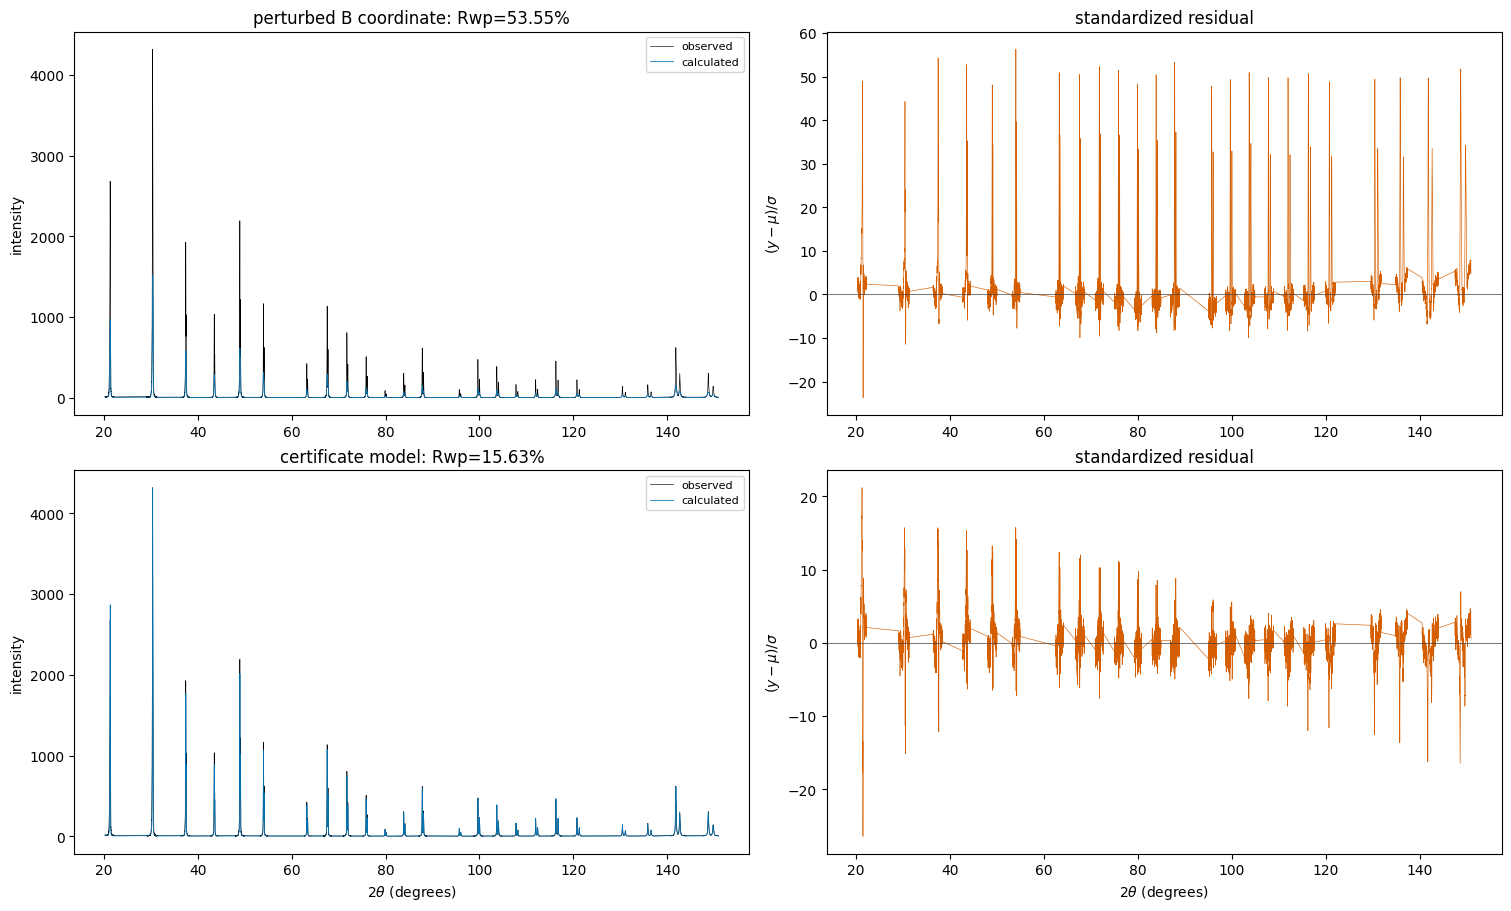

{'best candidate': 'certificate model',
 'stored points': 5332,
 'stored optimizer steps': 300,
 'stored run messages': 3}

In [7]:
print("Outer result type:", type(session_result).__name__)
print("One candidate type:", type(session_result.candidates[0]).__name__)
fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
for row, candidate in enumerate(session_result.candidates):
    axes[row, 0].plot(dataset.coordinate, dataset.intensity, color="black", lw=0.45,
                      label="observed")
    axes[row, 0].plot(dataset.coordinate, candidate.calculated, color="#0072B2", lw=0.55,
                      label="calculated")
    axes[row, 0].set(ylabel="intensity",
                     title=f"{candidate.name}: Rwp={100*candidate.r_wp:.2f}%")
    axes[row, 0].legend(fontsize=8)
    standardized = candidate.residual / dataset.sigma
    axes[row, 1].plot(dataset.coordinate, standardized, color="#D55E00", lw=0.45)
    axes[row, 1].axhline(0, color="0.25", lw=0.5)
    axes[row, 1].set(ylabel=r"$(y-\mu)/\sigma$", title="standardized residual")
axes[-1, 0].set_xlabel(r"$2\theta$ (degrees)")
axes[-1, 1].set_xlabel(r"$2\theta$ (degrees)")
plt.show()

best = next(c for c in session_result.candidates if c.name == session_result.ranking[0])
display({
    "best candidate": best.name,
    "stored points": len(best.calculated),
    "stored optimizer steps": len(best.loss_history),
    "stored run messages": len(best.warnings),
})


Read each row from left to right. The black line is the experiment and the blue line is the calculation. The orange residual shows the difference in units of \(\sigma\). A value near zero is a good match; a tall orange feature marks a peak whose position, height, or shape still needs work.

The perturbed model misses many peak heights. The certificate model follows them much more closely, which is why its `Rwp` is lower. The complete arrays used for these plots live directly in the `CandidateRefinementResult`.

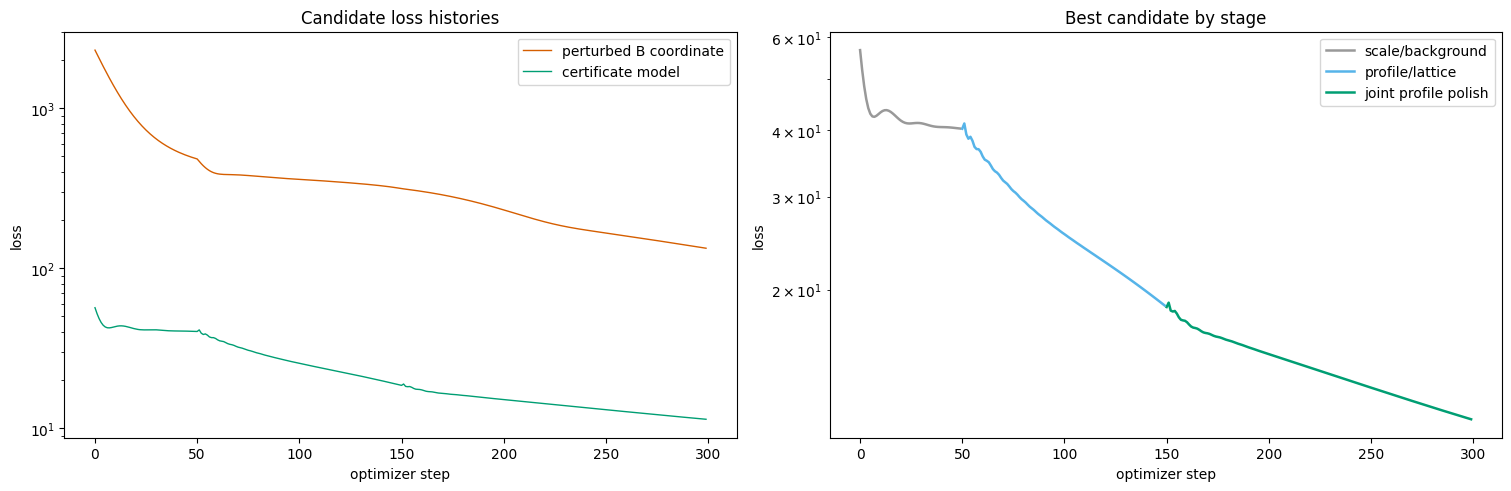

[{'stage': 'scale/background',
  'accepted': True,
  'loss before': 56.695910283579835,
  'loss after': 40.288568390341105,
  'gradient norm': 2.809126276016509},
 {'stage': 'profile/lattice',
  'accepted': True,
  'loss before': 40.288568390341105,
  'loss after': 18.5608225610494,
  'gradient norm': 8.508925297050268},
 {'stage': 'joint profile polish',
  'accepted': True,
  'loss before': 18.5608225610494,
  'loss after': 11.365958831937325,
  'gradient norm': 7.319042799188513}]

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
colors = ["#D55E00", "#009E73"]
for candidate, color in zip(session_result.candidates, colors):
    axes[0].semilogy(candidate.loss_history, color=color, lw=1, label=candidate.name)
axes[0].set(xlabel="optimizer step", ylabel="loss", title="Candidate loss histories")
axes[0].legend()

stage_names = np.asarray(best.stage_history)
for name, color in zip(dict.fromkeys(stage_names), ["#999999", "#56B4E9", "#009E73"]):
    indices = np.flatnonzero(stage_names == name)
    axes[1].semilogy(indices, best.loss_history[indices], color=color, lw=1.8, label=name)
axes[1].set(xlabel="optimizer step", ylabel="loss", title="Best candidate by stage")
axes[1].legend()
plt.show()

display([
    {
        "stage": item["name"],
        "accepted": item["accepted"],
        "loss before": item["training_before"],
        "loss after": item["training_after"],
        "gradient norm": item["gradient_norm"],
    }
    for item in best.convergence["stages"]
])


A falling loss curve means the optimizer is improving the fit. The right graph splits the best run into its three stages. Every stage was accepted because its final loss was lower than its starting loss: 56.70 → 40.29 → 18.56 → 11.37.

The gradient norm measures how strongly the loss is still pulling on the active parameters at the end of a stage. We use it together with the loss curve and held-out score when deciding whether to add more steps or release another parameter group.

## 7. See which parameters the pattern responds to

The green bars show how strongly each parameter changes the calculated pattern near the fitted solution. The color map shows how similarly pairs of parameters change it. Red means they move together; blue means they move in opposite directions.

The rank line underneath tells us how many independent parameter directions are present in this local calculation.


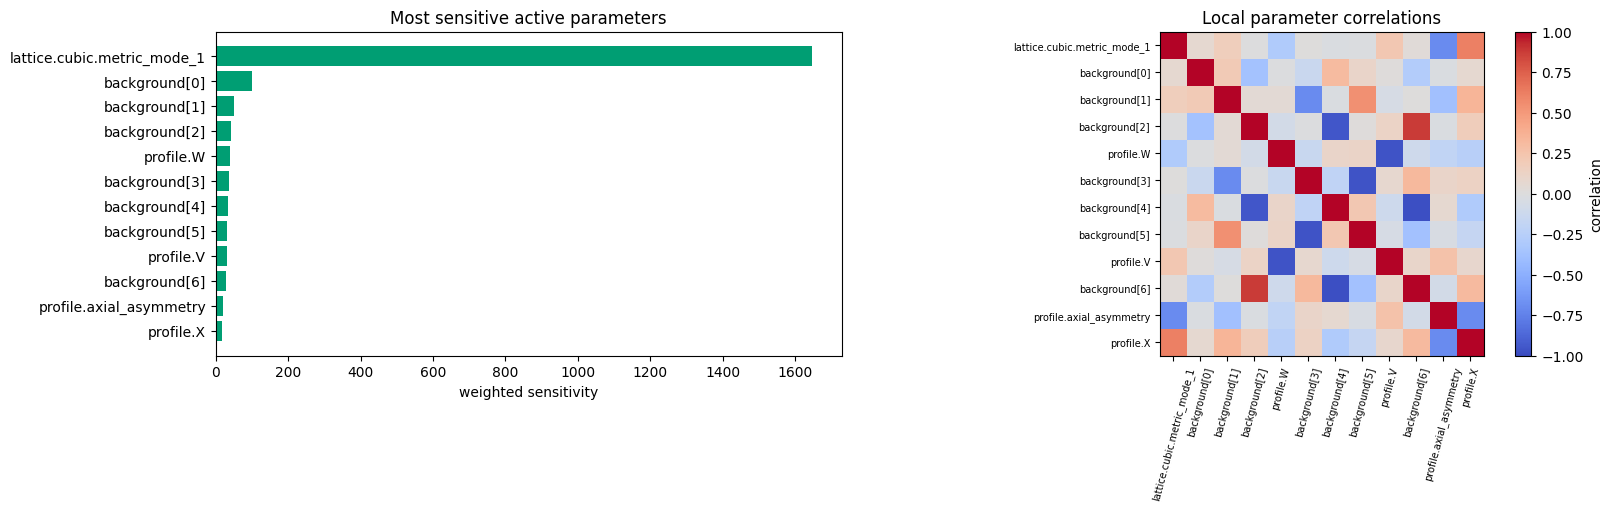

{'data rank / parameter count': '15 / 15',
 'data covariance identifiable': True,
 'posterior rank / parameter count': '15 / 15',
 'maximum absolute correlation': 0.9806305363966993}

In [9]:
identity = best.identifiability
names = np.asarray(identity["parameter_names"])
sensitivity = np.asarray(identity["sensitivity"])
correlation = np.asarray(identity["correlation"])
selected = np.argsort(sensitivity)[-12:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
axes[0].barh(np.arange(len(selected)), sensitivity[selected], color="#009E73")
axes[0].set(yticks=np.arange(len(selected)), yticklabels=names[selected],
            xlabel="weighted sensitivity", title="Most sensitive active parameters")
axes[0].invert_yaxis()
image = axes[1].imshow(correlation[np.ix_(selected, selected)],
                       vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set(xticks=np.arange(len(selected)), yticks=np.arange(len(selected)),
            xticklabels=names[selected], yticklabels=names[selected],
            title="Local parameter correlations")
axes[1].tick_params(axis="x", rotation=75, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)
fig.colorbar(image, ax=axes[1], label="correlation")
plt.show()
display({
    "data rank / parameter count": f"{identity['data_rank']} / {identity['parameter_count']}",
    "data covariance identifiable": identity["data_covariance_is_identifiable"],
    "posterior rank / parameter count": f"{identity['posterior_rank']} / {identity['parameter_count']}",
    "maximum absolute correlation": identity["maximum_absolute_correlation"],
})


The lattice parameter has the longest green bar, so tiny changes in the cell length have the largest effect on this pattern. All 15 active directions have information in the data: the rank is 15/15.

The largest absolute correlation is 0.981. That tells us that at least two active terms can partly compensate for one another. Releasing parameter families in stages helps us see which family produced each improvement.

## 8. Continue the best candidate and refine the boron coordinate

Every candidate result carries a checkpoint in `candidate.provenance["checkpoint"]`. Pass it to `refine_candidate()` to start the next set of stages from the saved parameter values.

Here we activate the boron coordinate, run a coordinate-only stage, and finish with a joint coordinate polish. For a whole candidate list, build a checkpoint dictionary like this:

```python
checkpoints = {c.name: c.provenance["checkpoint"] for c in result.candidates}
continued_result = session.run(new_policy, checkpoints=checkpoints)
```


{'resumed from checkpoint': True,
 'before Rwp (%)': 15.626364762938719,
 'after coordinate release Rwp (%)': 15.165820838496998,
 'coordinate parameter change': [-0.0003806306632245811],
 'data rank / parameter count': '16 / 16'}

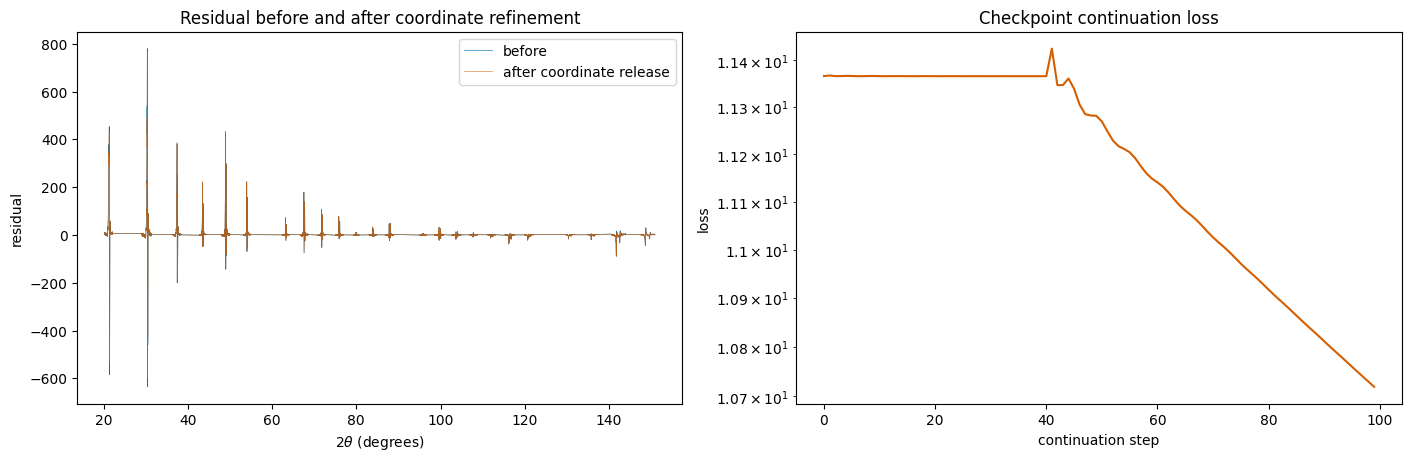

In [10]:
coordinate_policy = RefinementPolicy(
    background_degree=6, profile_model="tch", axial_asymmetry=True,
    goniometer_radius_mm=217.5, specimen_displacement_mm=-0.07877,
    refine_lattice=True, refine_coordinates=True, coordinate_restraint=0.05,
    holdout_stride=10, diagnostic_points=24,
    stages=(
        OptimizationStage("coordinates", ("coordinates",), 40, 0.001),
        OptimizationStage(
            "joint coordinate polish",
            ("scale", "background", "profile", "lattice", "coordinates"),
            60, 0.001,
        ),
    ),
)
best_index = model_names.index(best.name)
coordinate_fit = session.refine_candidate(
    best_index, policy=coordinate_policy, checkpoint=best.provenance["checkpoint"]
)
display({
    "resumed from checkpoint": coordinate_fit.provenance["resumed_from_checkpoint"],
    "before Rwp (%)": 100 * best.r_wp,
    "after coordinate release Rwp (%)": 100 * coordinate_fit.r_wp,
    "coordinate parameter change":
        coordinate_fit.physical_parameters["coordinate_displacements"],
    "data rank / parameter count":
        f"{coordinate_fit.identifiability['data_rank']} / {coordinate_fit.identifiability['parameter_count']}",
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].plot(dataset.coordinate, best.residual, color="#0072B2", lw=0.45, label="before")
axes[0].plot(dataset.coordinate, coordinate_fit.residual, color="#D55E00", lw=0.45,
             alpha=0.8, label="after coordinate release")
axes[0].set(xlabel=r"$2\theta$ (degrees)", ylabel="residual",
            title="Residual before and after coordinate refinement")
axes[0].legend()
axes[1].semilogy(coordinate_fit.loss_history, color="#D55E00")
axes[1].set(xlabel="continuation step", ylabel="loss",
            title="Checkpoint continuation loss")
plt.show()


The checkpoint restored the earlier scale, background, profile, and lattice values. Refining boron moved its independent coordinate by -0.00038 and lowered `Rwp` from 15.63% to 15.17%.

In the left graph, the orange residual sits a little closer to zero around several peaks. In the right graph, the continuation loss falls steadily. The new rank is 16/16, including the coordinate direction we just added.

## 9. Save the result

Use three small helpers for the usual outputs:

- `refined_structure_from_candidate()` makes the refined crystal structure;
- `session_result_to_dict()` makes a JSON-ready result;
- `session.write_html()` makes a report you can open in a browser.


In [11]:
refined_structure = refined_structure_from_candidate(coordinate_fit, dataset)
refined_cif = OUTPUT / "lab6-refined.cif"
CifWriter(refined_structure).write_file(refined_cif)

encoded = session_result_to_dict(session_result, run_id="advanced-session-tutorial")
result_json = OUTPUT / "session-result.json"
result_json.write_text(json.dumps(encoded, indent=2) + "\n", encoding="utf-8")
report_html = session.write_html(session_result, OUTPUT / "session-report.html")

display({
    "refined CIF": str(refined_cif.relative_to(ROOT)),
    "structured JSON": str(result_json.relative_to(ROOT)),
    "HTML report": str(report_html.relative_to(ROOT)),
    "result schema": encoded["schema"],
})


{'refined CIF': 'notebooks/session-tutorial-output/lab6-refined.cif',
 'structured JSON': 'notebooks/session-tutorial-output/session-result.json',
 'HTML report': 'notebooks/session-tutorial-output/session-report.html',
 'result schema': 'braggcalculator.session-result/v1'}

## 10. Fit two phases together

`RefinementSession` runs complete structural candidates one at a time. `PhaseMixtureSession` adds several phase profiles together.

We will combine LaB₆ and NaCl and refine their profile-area fractions. The result gives the fraction, component curve, total curve, residual, loss history, and parameter information.


{'Rwp (%)': 51.58018266964633,
 'profile-area fractions': {'LaB6': 0.9744875108886827,
  'NaCl impurity': 0.02551248911131737},
 'phase detectability scores': {'LaB6': 1020.1088263795821,
  'NaCl impurity': 488.96916560128454},
 'data rank / parameter count': '12 / 13'}

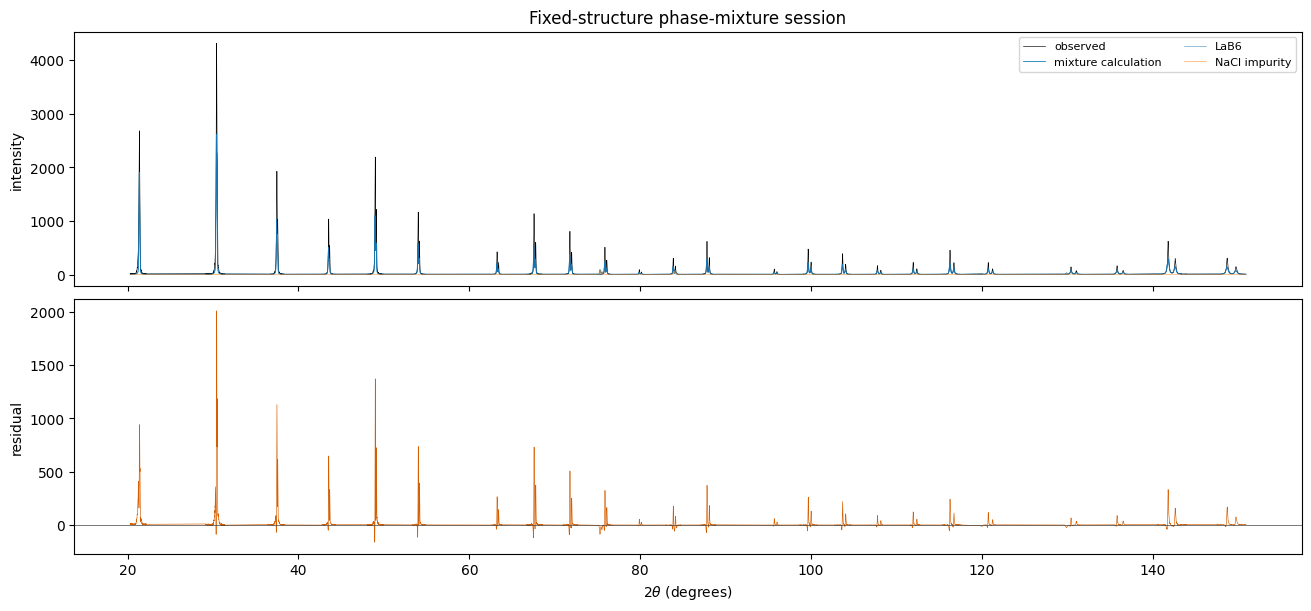

In [12]:
nacl = Structure.from_spacegroup(
    "Fm-3m", Lattice.cubic(5.64),
    ["Na", "Cl"], [[0, 0, 0], [0.5, 0.5, 0.5]],
)
mixture_policy = PhaseMixturePolicy(
    background_degree=4, initial_fractions=(0.9, 0.1), diagnostic_points=12,
    stages=(
        OptimizationStage("scale/background", ("scale", "background"), 30, 0.03),
        OptimizationStage("phase fractions", ("phase_fractions",), 50, 0.025),
        OptimizationStage(
            "joint", ("scale", "background", "phase_fractions", "profile"),
            70, 0.008,
        ),
    ),
)
mixture_result = PhaseMixtureSession(
    dataset, [certificate_model, nacl], names=["LaB6", "NaCl impurity"]
).run(mixture_policy)
display({
    "Rwp (%)": 100 * mixture_result.r_wp,
    "profile-area fractions": mixture_result.phase_fractions,
    "phase detectability scores": mixture_result.phase_detectability,
    "data rank / parameter count": (
        f"{mixture_result.identifiability['data_rank']} / "
        f"{mixture_result.identifiability['parameter_count']}"
    ),
})

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
axes[0].plot(dataset.coordinate, dataset.intensity, color="black", lw=0.45,
             label="observed")
axes[0].plot(dataset.coordinate, mixture_result.calculated, color="#0072B2", lw=0.55,
             label="mixture calculation")
for name, profile in mixture_result.component_profiles.items():
    axes[0].plot(dataset.coordinate, profile, lw=0.45, alpha=0.75, label=name)
axes[0].set(ylabel="intensity", title="Fixed-structure phase-mixture session")
axes[0].legend(fontsize=8, ncol=2)
axes[1].plot(dataset.coordinate, mixture_result.residual, color="#D55E00", lw=0.45)
axes[1].axhline(0, color="0.25", lw=0.5)
axes[1].set(xlabel=r"$2\theta$ (degrees)", ylabel="residual")
plt.show()


The fitted profile areas are 97.45% LaB₆ and 2.55% NaCl. The mixture `Rwp` is 51.58%, while the refined single-phase result above reached 15.17%. The single-phase result gives the closer description of this scan.

The mixture information rank is 12/13, so one fitted parameter combination is shared by other terms in this run. For a real multiphase sample, we would add the likely phases, refine the profile and lattice terms in stages, and compare the component peaks with the residual.

## 11. Structural parameter families

These switches cover the other refinement families in `RefinementPolicy`:

| Family | Switch | What it controls |
|---|---|---|
| Atomic coordinates | `refine_coordinates=True` | Symmetry-independent site positions |
| Site composition | `occupancy_mode="composition"` | Species fractions on a filled site |
| Vacancies | `occupancy_mode="vacancy"` | Species and vacancy fractions on a site |
| Isotropic displacement | `refine_b_iso=True` | One positive Biso per symmetry orbit |
| Anisotropic displacement | `refine_u_aniso=True` | A symmetry-compatible displacement tensor |
| Rigid bodies | `rigid_bodies=[...]` | Translation and rotation of a connected motif |
| Structural restraints | `structural_restraints={...}` | Bonds, angles, composition, and closest distances |
| Poisson counts | `likelihood="poisson"` | Count-data objective and mean Poisson deviance |
| Adaptive release | `adaptive_release=True` | Automatic sensitivity and correlation checks |
| Multiple attempts | `restarts=N` | Repeated fits with recorded seeds and outcomes |

A handy working order is scale/background → calibration/profile/lattice → coordinates or occupancies → displacement parameters → joint polish. Add one family, run it, and look at the fit, loss, held-out score, correlations, and refined values.


## What we finished

We loaded the full LaB₆ pattern and fitted two structural candidates. The certificate model reached 15.63% Rwp and ranked ahead of the shifted-boron candidate at 53.55% Rwp.

Then we continued the certificate model from its checkpoint, refined the boron coordinate, and reached 15.17% Rwp. We plotted the residual, optimizer loss, stage-by-stage progress, sensitivities, and parameter correlations.

Finally, we wrote a refined CIF, JSON result, and HTML report, and ran a two-phase LaB₆/NaCl mixture session. These are the main Session workflows you will use when building your own refinement script.
